In [ ]:
import os
subdir = ""
project_root = "/home/krzysztof/studia/magisterka/time-series-invariance"
os.chdir(os.path.join(project_root, subdir))

In [ ]:
import numpy as np


def convert(o):
    if isinstance(o, np.float32):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    raise TypeError(f"Type {type(o)} not serializable")



In [ ]:
import numpy as np

from src.embeddings.magnitude_spectrum import (
    band_energy_ratios,
    magnitude_spectrum,
    mfcc_features
)
from src.embeddings.seq2img_embeddings import s2i_vector
from src.embeddings.shape_based import paa, sax
from src.embeddings.simple_statistics import simple_statistics_vector
from src.embeddings.moments_1d import compute_1d_moment_vector

from notebooks.evaluations.helpers import (
    apply_embedding_function_shrunk,
    test_embeddings_quality,
    apply_embedding_function_shifts,

    )

import pandas as pd
import json

In [ ]:
def load_dataset(dataset_name):
    data_path = f"data/datasets/{dataset_name}.npz"
    data = np.load(data_path)
    return data["X"]

def load_distortions(dataset_name, distortion_type):
    data_path = f"data/distortions/{distortion_type}/{dataset_name}.npy"
    data = np.load(data_path)
    return data

In [ ]:
data_dir = "data/datasets"
dataset_names = [name[:-4] for name in os.listdir(data_dir)]
dataset_names

In [ ]:
def get_results(method_name, dataset_name, all_results, distortion_type, method):
    if method_name not in all_results:
        all_results[method_name] = {}

    data = load_dataset(dataset_name)
    random_shrunks = load_distortions(dataset_name, distortion_type)
    if distortion_type == "shift":
        embeddings = apply_embedding_function_shifts(data, method, random_shrunks)
    elif distortion_type == "shrink":
        embeddings = apply_embedding_function_shrunk(data, method, random_shrunks)
    else:
        raise ValueError(f"Unknown distortion type: {distortion_type}")
    print("embeddings shape:", embeddings.shape)

    _, results = test_embeddings_quality(embeddings)
    all_results[method_name][dataset_name] = results

In [ ]:
import pandas as pd

def get_result_df(all_results, metric_name):
    data_for_df = {}

    for method, datasets in all_results.items():
        row = {}
        for dataset, metrics in datasets.items():
            row[dataset] = metrics[metric_name]
        data_for_df[method] = row

    df = pd.DataFrame.from_dict(data_for_df, orient='index')

    return df

## Shrunk invariance

In [ ]:
all_results_shrink_path = "results/shrink_results.json"
if os.path.exists(all_results_shrink_path):
    try:
        with open(all_results_shrink_path, "r") as f:
            all_results_shrink = json.load(f)
    except json.JSONDecodeError:
        print(f"Error decoding JSON from {all_results_shrink_path}. Starting with an empty dictionary.")
        all_results_shrink = {}
else:
    all_results_shrink = {}

### 1d moments

In [ ]:
method_name = "1d_moments"
for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", compute_1d_moment_vector)
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### Simple embedding vector

In [ ]:
method_name = "simple_embedding_vector"
for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", simple_statistics_vector)
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### Magnitude spectrum
Because it works on fix bands it does terribly after shrinking.

In [ ]:
method_name = "band_energy_ratios"
bands_i = np.linspace(0, 1, 10)
bands = [(bands_i[i], bands_i[i+1]) for i in range(len(bands_i)-1)]

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x : band_energy_ratios(x, 1, bands))
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
method_name = "mfcc_features"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x : mfcc_features(x, 1, 12))
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### Sequence to image hu vector

In [ ]:
img_name = "PSI"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
img_name = "MTF"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
img_name = "RP"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
img_name = "GAF"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
img_name = "STFT"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)], stft_parameters=[(64, 32)],)[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

In [ ]:
img_name = "Plain_Tile"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### PAA

In [ ]:
method_name = "PAA"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: paa(x, 20))
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### SAX

In [ ]:
method_name = "SAX"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: sax(x, 20, 5))
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### ts2vec transfer

In [ ]:
all_results_shrink["ts2vec"] = {}
for dataset_name in dataset_names:
    embeddings = np.load(f"notebooks/evaluations/embeddings/ts2vec/shrink/{dataset_name}.npy")
    _, results = test_embeddings_quality(embeddings)
    for key in results:
        if isinstance(results[key], np.float32):
            results[key] = float(results[key])
    all_results_shrink["ts2vec"][dataset_name] = results
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4, default=convert)

In [ ]:
test_embeddings_quality(embeddings)

### Summary

In [96]:
global_cos_sim_df = get_result_df(all_results_shrink, "global_cos_sim")
local_cos_sim_df = get_result_df(all_results_shrink, "local_cos_sim")
global_cos_sim_df

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,0.541094,0.524922,0.950291,0.966706,0.876582,0.581788,0.798397,0.605633,0.748722,0.562134,0.389293,0.440152,0.588746,0.972903,0.938784,0.999999,0.495232
simple_embedding_vector,0.978847,0.992726,0.998105,0.998197,0.965151,0.932550,0.990404,0.986949,0.992605,0.992339,0.940303,0.988991,0.955997,0.997848,0.998972,0.999993,0.988882
band_energy_ratios,0.998727,0.999999,1.000000,0.999904,0.977582,0.979043,0.999114,0.917507,0.851030,0.999783,0.999765,0.999999,0.999996,0.999491,0.999999,1.000000,0.997808
mfcc_features,0.998081,0.994552,0.999803,0.999923,0.987593,0.997256,0.998979,0.991346,0.992320,0.997990,0.996674,0.995159,0.998558,0.997142,0.999853,0.999922,0.992854
seq2img_PSI,0.527663,0.901237,0.856612,0.943706,0.079255,0.252270,0.678625,0.842511,0.108954,0.793275,0.225329,0.408132,0.078131,0.379001,0.883974,0.851441,0.179390
seq2img_MTF,0.796002,0.960610,0.985430,0.975666,0.862374,0.800370,0.971728,0.879145,0.780317,0.896506,0.641612,0.929981,0.852194,0.820486,0.991539,0.998754,0.880484
seq2img_RP,0.999977,1.000000,1.000000,1.000000,0.999259,0.999977,1.000000,0.999996,0.999761,0.999999,0.998334,0.999979,0.999987,0.999992,1.000000,1.000000,0.999962
seq2img_GAF,0.910559,0.660281,0.954529,0.710718,0.152691,0.169923,0.974838,0.831892,0.798687,0.800653,0.065637,0.505632,0.075561,0.723597,0.710123,0.170138,0.947797
seq2img_STFT,0.999778,0.993018,0.999988,0.998730,0.999715,0.997260,0.999978,0.997062,0.840269,0.996338,0.999716,0.983576,0.999993,0.999930,0.999455,0.990623,0.999981
seq2img_Plain_Tile,0.700228,0.761081,0.825497,0.811040,0.809549,0.552495,0.827412,0.535648,0.482048,0.831232,0.799209,0.764336,0.858423,0.498768,0.839897,0.829151,0.502569


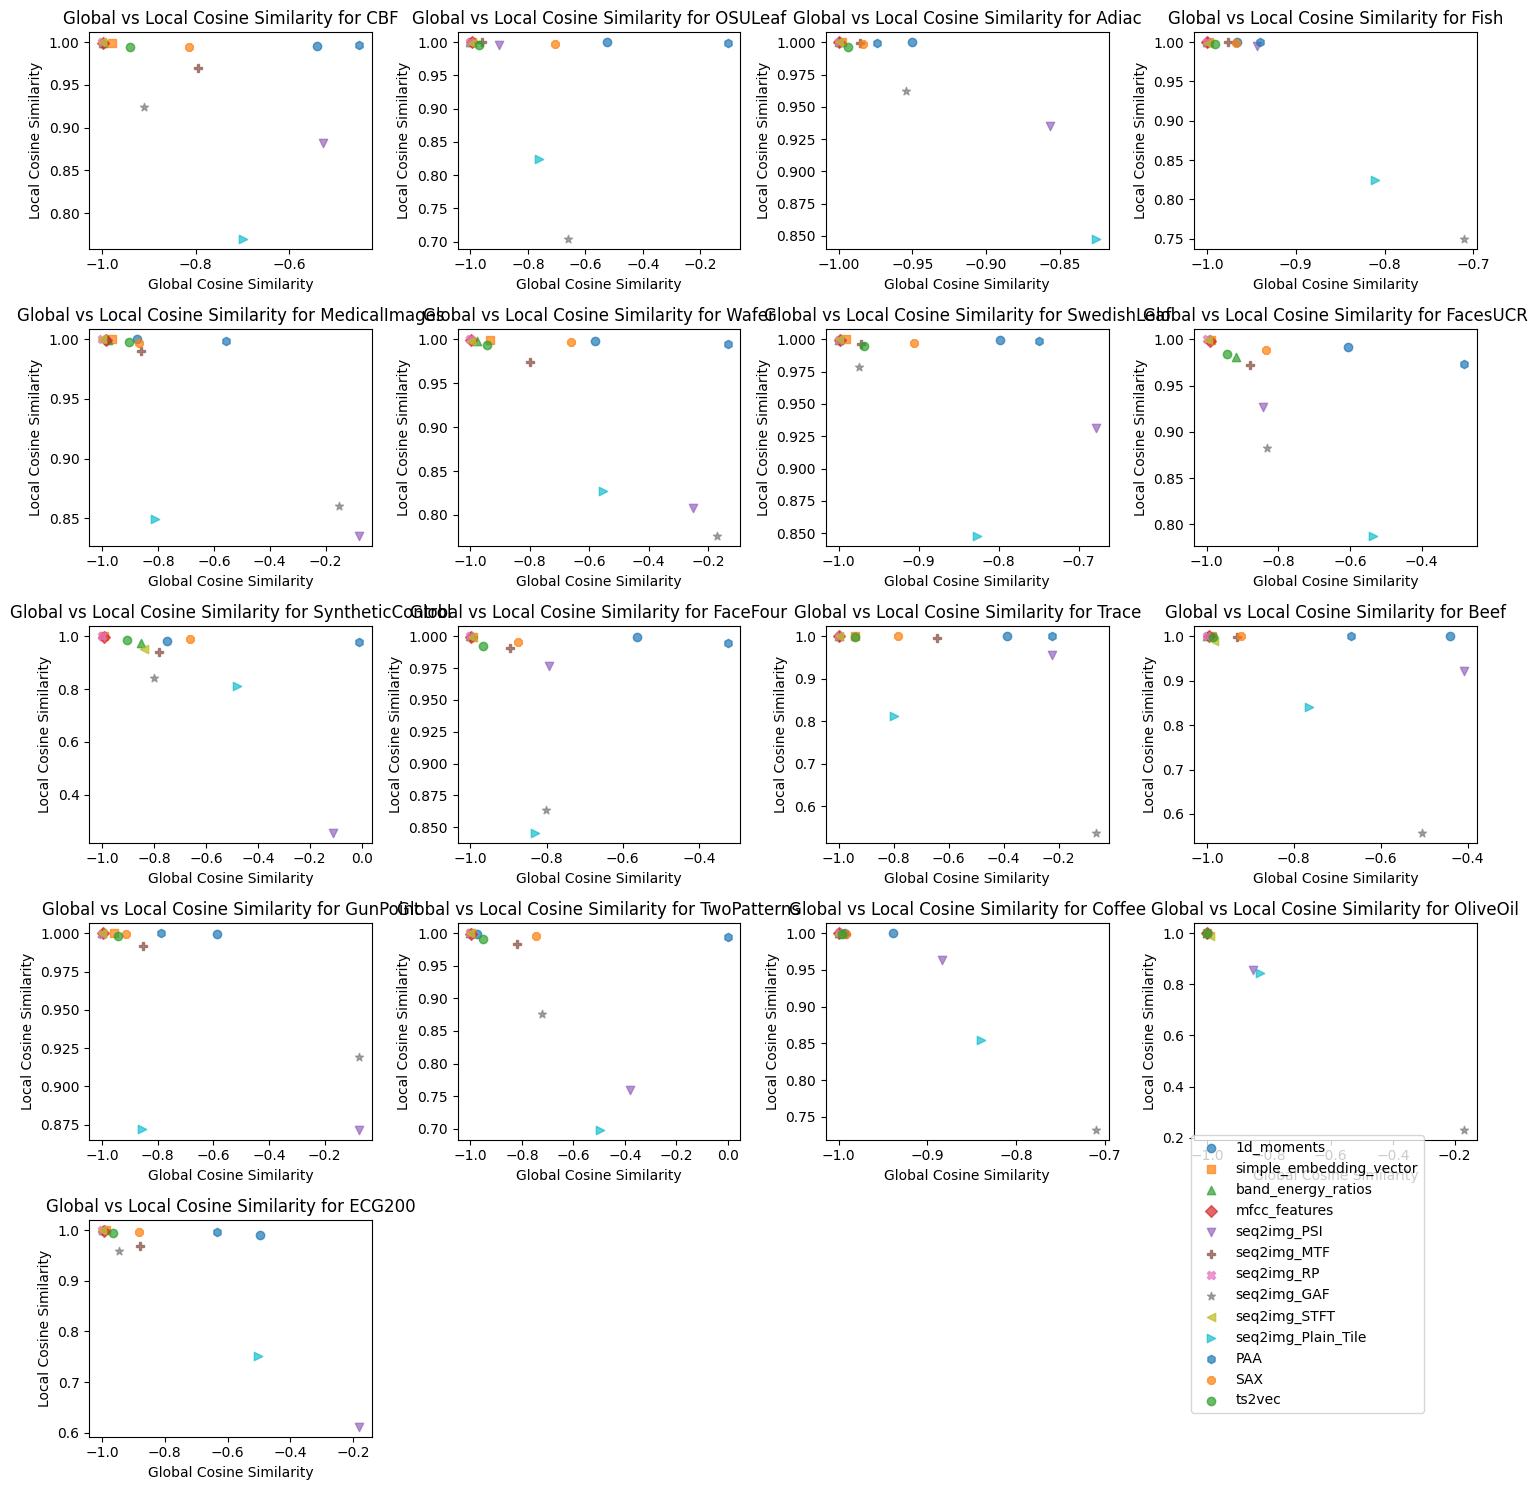

In [97]:
from matplotlib import pyplot as plt
import numpy as np
import itertools

fig, axes = plt.subplots(5, 4, figsize=(15, 15))
axes = axes.flatten()

num_datasets = len(dataset_names)

# Marker styles to cycle through
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>', 'h', '8']
marker_cycle = itertools.cycle(markers)

# Assign a marker to each method
method_markers = {method: next(marker_cycle) for method in global_cos_sim_df.index}

for i, dataset_name in enumerate(dataset_names):
    for method_name in global_cos_sim_df.index:
        x = global_cos_sim_df.loc[method_name][dataset_name] * -1
        y = local_cos_sim_df.loc[method_name][dataset_name]

        x_jitter = x + np.random.normal(0, 0.0001, size=np.shape(x))
        y_jitter = y + np.random.normal(0, 0.0001, size=np.shape(y))

        axes[i].scatter(
            x_jitter,
            y_jitter,
            label=method_name,
            alpha=0.7,
            marker=method_markers[method_name]   # <- marker added
        )

    axes[i].set_xlabel("Global Cosine Similarity")
    axes[i].set_ylabel("Local Cosine Similarity")
    axes[i].set_title(f"Global vs Local Cosine Similarity for {dataset_name}")

# Hide unused axes
for j in range(num_datasets, len(axes)):
    axes[j].axis('off')

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.95, 0.05))

plt.tight_layout()
plt.show()

In [98]:
silhouette_score = get_result_df(all_results_shrink, "slihouette_score_max")
silhouette_score.style.highlight_max(axis=0)

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,-0.390284,0.742028,0.053444,0.846059,0.028119,-0.143504,0.211693,-0.194881,-0.386503,0.442248,0.405662,0.964851,0.294358,-0.308797,0.808820,-0.311947,-0.094699
simple_embedding_vector,-0.317149,0.866600,0.213804,0.807739,0.704035,-0.033346,0.381900,-0.089003,-0.189883,0.697219,0.340620,0.912924,0.622479,-0.165292,0.682512,-0.276038,0.215288
band_energy_ratios,-0.363007,-0.502625,-0.551403,-0.560660,-0.361170,-0.485242,-0.477180,-0.560575,-0.338242,-0.306170,-0.296958,-0.315536,-0.500467,-0.442313,-0.452824,-0.211164,-0.320056
mfcc_features,-0.171477,0.202292,-0.087114,0.062581,0.127618,-0.265685,0.084622,-0.056522,-0.093601,-0.075096,0.075728,-0.141549,0.082080,-0.189022,-0.104564,-0.182692,0.012768
seq2img_PSI,-0.509991,-0.313796,-0.309761,-0.432662,-0.471132,-0.484547,-0.453002,-0.492517,-0.477150,-0.267499,-0.327057,-0.033158,-0.335749,-0.567654,-0.295982,-0.299892,-0.547279
seq2img_MTF,-0.459402,-0.212913,-0.374865,-0.287114,-0.378831,-0.310238,-0.432412,-0.483272,-0.504651,-0.188344,-0.258932,-0.071996,-0.278545,-0.304047,-0.223490,-0.280985,-0.431661
seq2img_RP,-0.235750,0.777124,-0.328713,0.539329,0.599467,0.089310,-0.051523,0.222521,-0.486256,0.833955,0.441299,0.928527,0.243160,-0.190826,0.264167,-0.168736,0.471038
seq2img_GAF,-0.619524,-0.193818,-0.301517,-0.214575,-0.235282,-0.261647,-0.456888,-0.512708,-0.425271,-0.096752,-0.186019,-0.025112,0.028081,-0.442258,0.002309,-0.004153,-0.421193
seq2img_STFT,-0.599206,-0.544127,-0.430692,-0.399172,-0.265303,-0.601857,-0.613622,-0.559668,-0.598791,-0.472842,-0.495878,-0.414656,-0.607793,-0.613946,-0.337420,-0.195724,-0.602745
seq2img_Plain_Tile,-0.773769,-0.703817,-0.806769,-0.712441,-0.716676,-0.824319,-0.789089,-0.820543,-0.772794,-0.742781,-0.596634,-0.614099,-0.626357,-0.847680,-0.611510,-0.558947,-0.771599


In [99]:
cohen_d = get_result_df(all_results_shrink, "cohen_d")
cohen_d.style.highlight_max(axis=0)

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,1.114235,1.357714,0.732364,0.858609,0.540958,1.416952,0.886852,1.204553,1.149086,1.063716,1.125683,1.364875,1.214097,1.064661,0.964248,0.758441,1.293965
simple_embedding_vector,1.348297,1.434593,0.772117,0.241105,1.078914,1.177384,1.293087,0.913595,1.234948,1.253280,1.576458,0.931287,1.448888,0.849800,1.436533,0.839053,1.194799
band_energy_ratios,0.789899,0.804313,0.139878,0.066644,0.747093,0.443955,0.234196,0.845850,0.721796,0.556163,0.840537,0.886731,0.188043,0.535049,0.410061,0.001616,0.748519
mfcc_features,0.862037,0.825528,0.452188,0.113679,1.572432,0.781624,1.119704,1.211976,1.622171,0.965254,1.312848,0.695414,0.902036,0.800244,1.140105,0.009270,1.283148
seq2img_PSI,1.245376,0.776385,0.534708,0.767317,1.506011,1.044077,1.242824,0.531969,0.305301,0.782470,1.614871,1.563767,1.407259,1.005732,0.902670,0.021406,0.847148
seq2img_MTF,1.205454,0.647922,0.386126,0.698403,0.936714,0.979408,0.462921,1.032286,0.943787,0.783878,1.685194,0.914830,1.157896,0.963887,0.750637,0.846850,0.841625
seq2img_RP,0.509820,0.451321,0.219349,0.564127,1.190357,0.166467,0.224151,0.663842,1.275019,0.587058,1.408440,1.004304,0.248465,0.876642,0.635416,0.957623,0.554239
seq2img_GAF,0.048681,0.094399,0.038816,0.087878,1.652360,0.970084,0.023877,0.138213,0.110484,0.168985,0.963563,0.103885,1.565924,0.390479,0.049113,0.151360,0.050724
seq2img_STFT,0.130544,0.537564,0.253024,0.403240,0.349923,0.072631,0.707827,0.103450,0.424954,0.925789,0.765779,0.245768,0.379651,0.136810,0.045723,0.002680,0.141111
seq2img_Plain_Tile,0.157970,0.154437,0.060189,0.034554,0.105300,0.623248,0.055903,0.562732,0.738293,0.038813,0.033250,0.192801,0.039798,0.416055,0.041421,0.036291,0.532410


In [100]:
fdr = get_result_df(all_results_shrink, "FDR")
fdr.style.highlight_max(axis=0)

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,0.620759,0.921694,0.268178,0.368605,0.146318,1.003876,0.393254,0.725474,0.660200,0.565746,0.633581,0.931442,0.737015,0.566751,0.464887,0.287616,0.837173
simple_embedding_vector,0.908952,1.029029,0.298082,0.029066,0.582028,0.693116,0.836037,0.417328,0.762548,0.785356,1.242610,0.433648,1.049638,0.361080,1.031813,0.352005,0.713772
band_energy_ratios,0.311970,0.323460,0.009783,0.002221,0.279074,0.098548,0.027424,0.357731,0.260495,0.154659,0.353251,0.393146,0.017680,0.143139,0.084075,0.000001,0.280140
mfcc_features,0.371553,0.340748,0.102237,0.006461,1.236271,0.305468,0.626869,0.734443,1.315719,0.465858,0.861785,0.241800,0.406835,0.320195,0.649920,0.000043,0.823234
seq2img_PSI,0.775481,0.301387,0.142956,0.294388,1.134034,0.545048,0.772306,0.141496,0.046604,0.306130,1.303904,1.222683,0.990190,0.505748,0.407407,0.000229,0.358830
seq2img_MTF,0.726560,0.209902,0.074546,0.243883,0.438716,0.479620,0.107148,0.532807,0.445367,0.307232,1.419939,0.418457,0.670361,0.464539,0.281728,0.358577,0.354166
seq2img_RP,0.129958,0.101845,0.024057,0.159120,0.708475,0.013856,0.025122,0.220343,0.812836,0.172319,0.991851,0.504313,0.030867,0.384250,0.201876,0.458521,0.153591
seq2img_GAF,0.001185,0.004456,0.000753,0.003861,1.365147,0.470531,0.000285,0.009551,0.006103,0.014278,0.464227,0.005396,1.226059,0.076237,0.001206,0.011455,0.001286
seq2img_STFT,0.008521,0.144488,0.032011,0.081301,0.061223,0.002638,0.250510,0.005351,0.090293,0.428542,0.293209,0.030201,0.072067,0.009358,0.001045,0.000004,0.009956
seq2img_Plain_Tile,0.012477,0.011925,0.001811,0.000597,0.005544,0.194219,0.001563,0.158334,0.272538,0.000753,0.000553,0.018586,0.000792,0.086551,0.000858,0.000659,0.141730


## Shift invariance

In [ ]:
all_results_shift_path = "results/shift_results.json"
if os.path.exists(all_results_shift_path):
    with open(all_results_shift_path, "r") as f:
        all_results_shift = json.load(f)
else:
    all_results_shift = {}

### 1d moments

In [ ]:
method_name = "1d_moments"
for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", compute_1d_moment_vector)
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

### Simple embedding vector

In [ ]:
method_name = "simple_embedding_vector"
for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", simple_statistics_vector)
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

### Magnitude spectrum

In [ ]:
method_name = "band_energy_ratios"
bands_i = np.linspace(0, 1, 10)
bands = [(bands_i[i], bands_i[i+1]) for i in range(len(bands_i)-1)]

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x : band_energy_ratios(x, 1, bands))
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
method_name = "mfcc_features"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x : mfcc_features(x, 1, 12))
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

### Sequence to image hu vector

In [ ]:
img_name = "PSI"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(10, 4, 16)])[0])
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
img_name = "MTF"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)], markov_bins=4)[0])
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
img_name = "RP"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
img_name = "GAF"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
img_name = "STFT"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: s2i_vector(x, name=img_name, stft_parameters = [(16, 4)])[0])
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

In [ ]:
img_name = "Plain_Tile"
method_name = f"seq2img_{img_name}"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shrink, "shrink", lambda x: s2i_vector(x, name=img_name, psi_parameters=[(16, 4, 16)])[0])
with open(all_results_shrink_path, "w") as f:
    json.dump(all_results_shrink, f, indent=4)

### PAA

In [ ]:
method_name = "PAA"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: paa(x, 20))
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

### SAX

In [ ]:
method_name = "SAX"

for dataset_name in dataset_names:
    get_results(method_name, dataset_name, all_results_shift, "shift", lambda x: sax(x, 20, 5))
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4)

### ts2vec transfer

In [ ]:
all_results_shift["ts2vec"] = {}
for dataset_name in dataset_names:
    embeddings = np.load(f"notebooks/evaluations/embeddings/ts2vec/shift/{dataset_name}.npy")
    _, results = test_embeddings_quality(embeddings)
    all_results_shift["ts2vec"][dataset_name] = results
with open(all_results_shift_path, "w") as f:
    json.dump(all_results_shift, f, indent=4, default=convert)

### Summary

In [101]:
global_cos_sim_df = get_result_df(all_results_shift, "global_cos_sim")
local_cos_sim_df = get_result_df(all_results_shift, "local_cos_sim")
global_cos_sim_df

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,0.468603,0.527672,0.951787,0.967830,0.704005,0.442126,0.848427,0.506859,0.731156,0.593491,0.359592,0.478972,0.433516,0.913629,0.801360,0.999471,0.339466
simple_embedding_vector,0.980915,0.991407,0.997752,0.997697,0.887305,0.909007,0.989813,0.986369,0.986320,0.991808,0.920582,0.979928,0.945118,0.976110,0.992291,0.998222,0.966897
band_energy_ratios,0.997349,0.999979,0.999966,0.999841,0.984647,0.984877,0.999547,0.931634,0.839390,0.999506,0.999910,0.999998,0.999982,0.998706,0.999990,1.000000,0.997871
mfcc_features,0.998154,0.997366,0.999727,0.999794,0.988447,0.997218,0.998669,0.990647,0.992453,0.997611,0.996715,0.997558,0.998410,0.997954,0.999437,0.999349,0.990846
seq2img_PSI,0.658137,0.830236,0.763919,0.864453,0.091378,0.095520,0.618281,0.802486,0.521653,0.747522,0.478946,0.573402,0.679692,0.282900,0.743656,0.996397,0.303884
seq2img_MTF,0.993708,0.999865,0.999930,0.999949,0.979263,0.997951,0.999758,0.999862,0.991753,0.999939,0.987174,0.985961,0.987351,0.999095,0.995586,0.998110,0.989262
seq2img_RP,0.999835,0.999999,1.000000,1.000000,0.983159,0.997780,0.999999,0.999995,0.999838,0.999995,0.995214,0.999934,0.998292,0.999987,0.999947,0.999974,0.999790
seq2img_GAF,0.872207,0.602596,0.910750,0.600109,0.230442,0.175013,0.899530,0.828536,0.803684,0.803234,0.151023,0.609595,0.287593,0.722329,0.745326,0.191264,0.863839
seq2img_STFT,0.997869,0.953361,0.995119,0.993782,0.857353,0.936485,0.993281,0.968154,0.964037,0.787061,0.893593,0.779909,0.987576,0.991546,0.937424,0.997957,0.961364
PAA,0.256519,0.047040,0.760984,0.205845,0.369395,0.079154,0.187547,0.067374,0.000861,0.130867,0.208918,0.363002,0.474175,0.000423,0.400706,0.475169,0.282667


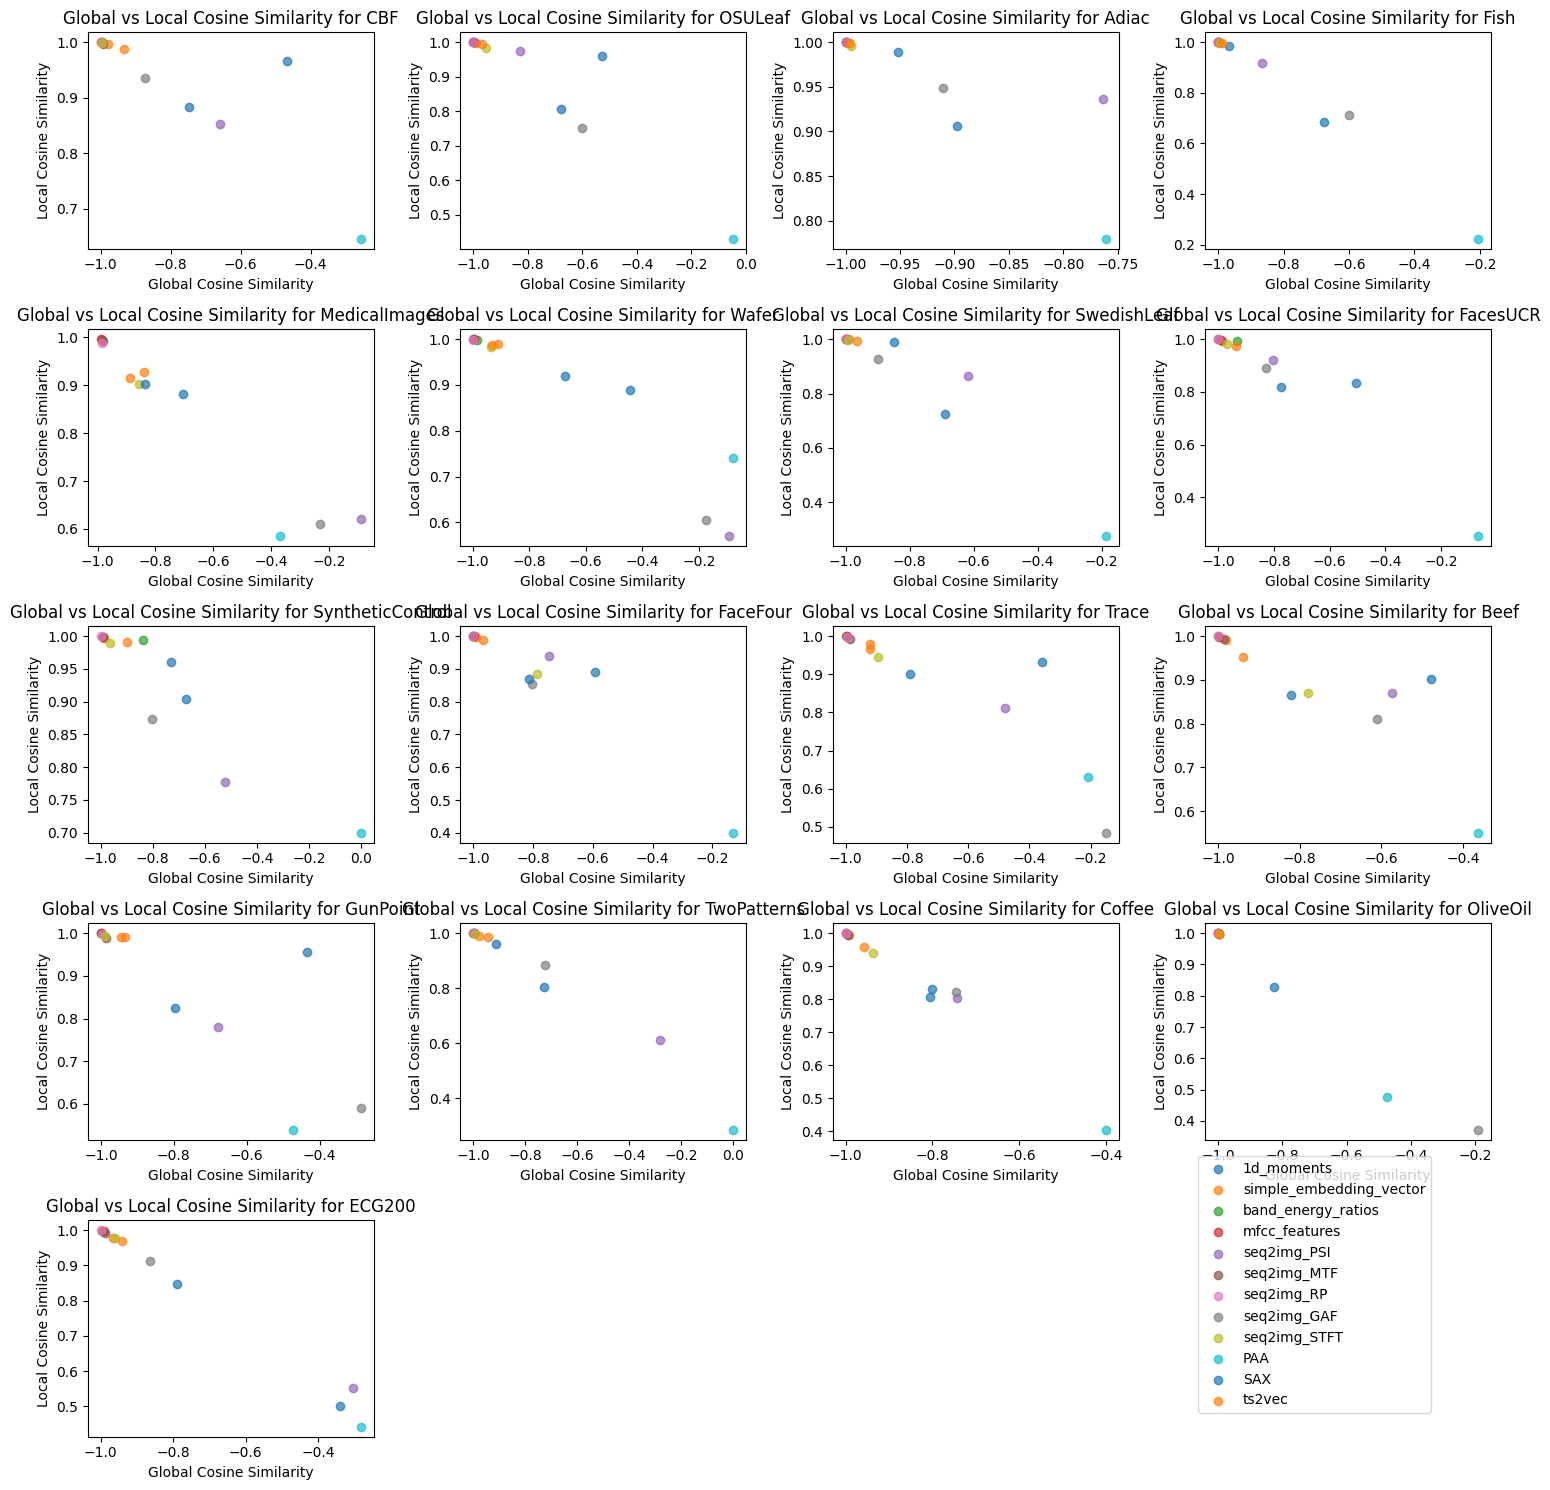

In [102]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(5, 4, figsize=(15, 15))
axes = axes.flatten()

num_datasets = len(dataset_names)

for i, dataset_name in enumerate(dataset_names):
    for method_name in global_cos_sim_df.index:
        x = global_cos_sim_df.loc[method_name][dataset_name] * -1
        y = local_cos_sim_df.loc[method_name][dataset_name]
        x_jitter = x + np.random.normal(0, 0.0001, size=np.shape(x))
        y_jitter = y + np.random.normal(0, 0.0001, size=np.shape(y))
        axes[i].scatter(
            x_jitter,
            y_jitter,
            label=method_name,
            alpha=0.7
        )
    axes[i].set_xlabel("Global Cosine Similarity")
    axes[i].set_ylabel("Local Cosine Similarity")
    axes[i].set_title(f"Global vs Local Cosine Similarity for {dataset_name}")

# Hide any unused axes
for j in range(num_datasets, len(axes)):
    axes[j].axis('off')  # or axes[j].set_visible(False)

# Single legend at bottom right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(0.95, 0.05))

plt.tight_layout()
plt.show()

In [103]:
cohen_d = get_result_df(all_results_shift, "cohen_d")
cohen_d.style.highlight_max(axis=0)

,CBF,OSULeaf,Adiac,Fish,MedicalImages,Wafer,SwedishLeaf,FacesUCR,SyntheticControl,FaceFour,Trace,Beef,GunPoint,TwoPatterns,Coffee,OliveOil,ECG200
1d_moments,1.195786,1.194779,0.443915,0.391380,0.391237,1.069474,0.621614,0.707852,1.030166,0.644603,0.994838,0.918257,1.282135,0.483573,0.110895,0.000816,0.243463
simple_embedding_vector,1.158130,1.348688,0.802713,0.179493,0.196672,1.195369,1.303434,0.555186,1.265875,0.684028,0.644472,0.574141,1.121825,0.455078,0.131376,0.001572,0.365982
band_energy_ratios,0.635304,0.358915,0.078379,0.049349,0.321716,0.346400,0.323488,0.834622,0.977223,0.285859,0.626172,0.399680,0.313962,0.669320,0.020120,0.000223,0.215943
mfcc_features,1.943449,0.514087,0.389306,0.053762,0.853863,0.791654,1.182105,0.966453,2.286878,1.638190,1.107985,0.384142,0.747728,1.707036,0.171703,0.002616,0.808039
seq2img_PSI,0.635826,0.809940,0.846346,0.291157,0.934661,0.673708,0.898925,0.590946,0.799039,0.744832,0.736838,0.873757,0.219649,0.650298,0.270616,0.160383,0.522183
seq2img_MTF,0.301564,0.105766,0.183190,0.083500,0.722060,0.304826,0.141851,0.222021,0.874988,0.222025,0.300929,0.522922,0.141803,0.135568,0.048334,0.002352,0.186479
seq2img_RP,0.301532,0.091781,0.139871,0.053199,0.115937,0.024253,0.124414,0.475112,1.205110,0.236721,0.313915,0.172229,0.039344,0.380331,0.039258,0.000561,0.211794
seq2img_GAF,0.211896,0.323904,0.149960,0.238785,0.744406,0.760088,0.099764,0.177436,0.193210,0.131282,0.643939,0.458776,0.587434,0.420331,0.188079,0.418273,0.163900
seq2img_STFT,0.410081,0.405541,0.104480,0.089656,0.268394,0.449284,0.496776,0.400049,0.879231,0.482635,0.515722,0.370138,0.396013,0.423530,0.036646,0.000330,0.260429
PAA,0.944085,0.876606,0.061900,0.024939,0.551594,1.409108,0.145047,0.465888,1.653077,0.657726,0.956605,0.297393,0.164428,0.640357,0.005640,0.000062,0.297726
